<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# PINNS

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import time
import math
import os


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split



from tqdm import tqdm

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


# Question 1

=== WAVE DATA GENERATION ===
Generated 2000 polynomial functions
Coefficient shape: (2000, 3) (a, w, phi for a*sin(w*x + phi))
Spatial domain: x ∈ [-1.0, 1.0] with 100 points
Functions shape: (2000, 100)
Derivatives shape: (2000, 100)


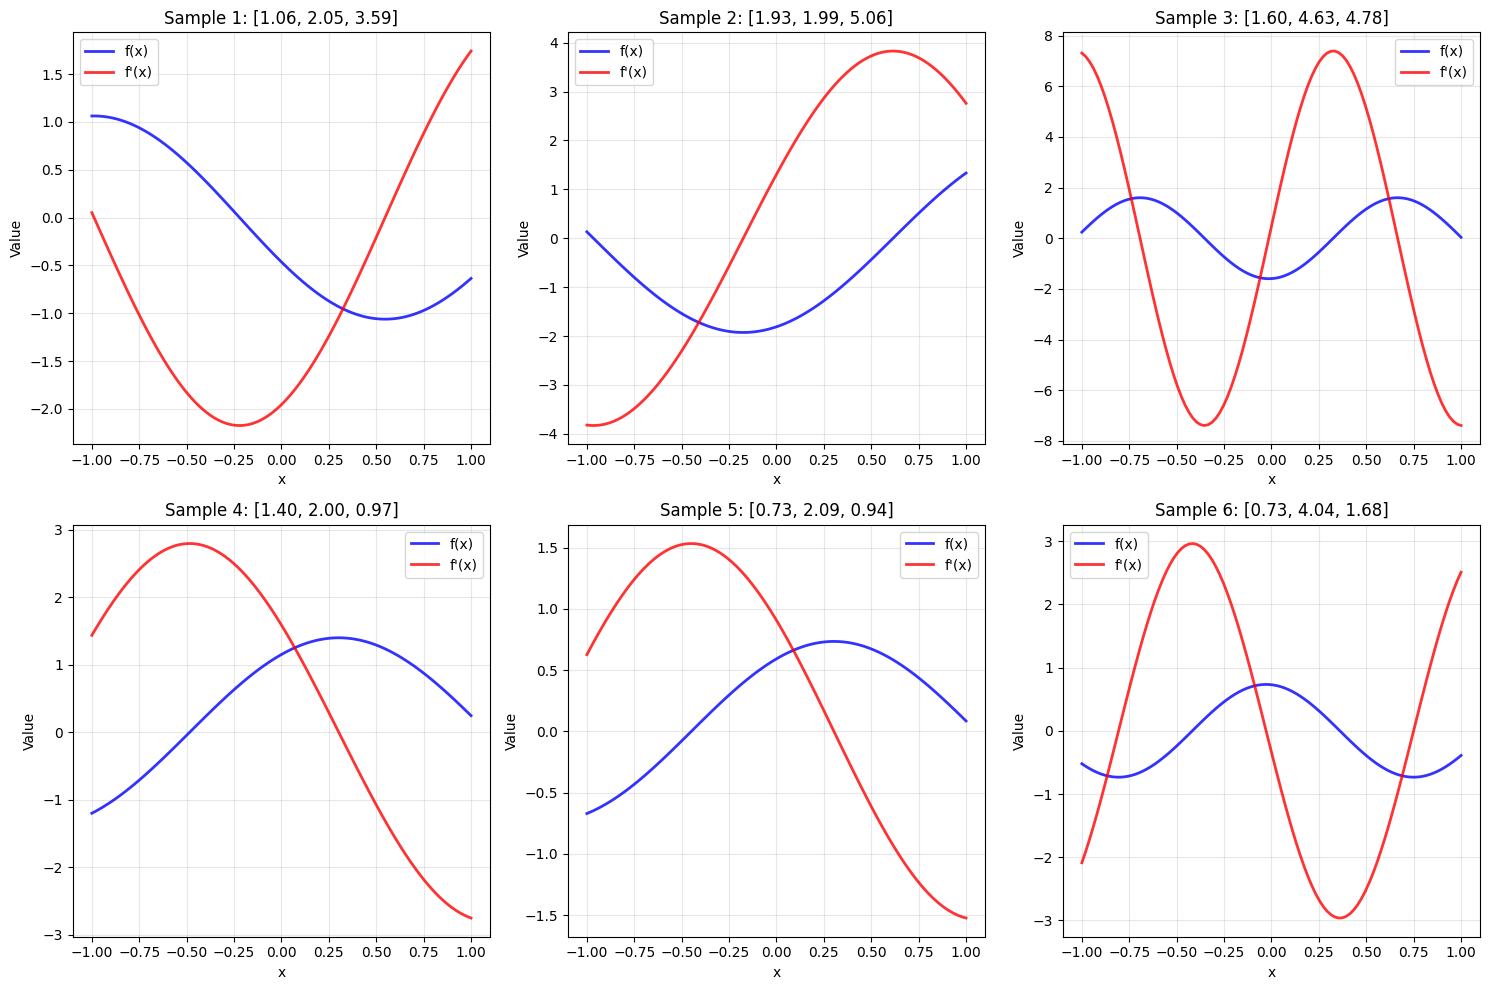


Mathematical relationships:
f(x) = a*sin(w*x + phi)
f'(x) = a*w*cos(w*x + phi)
Goal: Learn operator mapping [a,w,phi] → f'(x)


In [22]:
# ========================= CELL 1: Data Generation =========================
def generate_polynomial_data(num_functions=2000, num_points=100, x_range=(-1, 1)):
    """Generate cubic polynomial functions and their derivatives"""
    np.random.seed(42)
    
    # Generate random coefficients for cubic polynomials: ax^3 + bx^2 + cx + d
    # Sample parameters
    a_values = np.random.uniform(0.5, 2.0, size=num_functions)        # Amplitude
    w_values = np.random.uniform(1.0, 5.0, size=num_functions)    # Frequency
    phi_values = np.random.uniform(0.0, 2 * np.pi, size=num_functions)  # Phase

    # Generate spatial points
    x = np.linspace(x_range[0], x_range[1], num_points)
    
    # Initialize arrays
    functions = np.zeros((num_functions, num_points))
    derivatives = np.zeros((num_functions, num_points))
    
    for i in range(num_functions):
        a, w, phi = a_values[i], w_values[i], phi_values[i]
        # f(x) = a*sin(w*x + phi)
        functions[i] = a * np.sin(w * x + phi)
        # f'(x) = a*w*cos(w*x + phi)
        derivatives[i] = a * w * np.cos(w * x + phi)

    return np.column_stack((a_values, w_values, phi_values)), x, functions, derivatives

print("=== WAVE DATA GENERATION ===")
coeffs, x, functions, derivatives = generate_polynomial_data(num_functions=2000, num_points=100)
print(f"Generated {len(coeffs)} polynomial functions")
print(f"Coefficient shape: {coeffs.shape} (a, w, phi for a*sin(w*x + phi))")
print(f"Spatial domain: x ∈ [{x[0]:.1f}, {x[-1]:.1f}] with {len(x)} points")
print(f"Functions shape: {functions.shape}")
print(f"Derivatives shape: {derivatives.shape}")


# Visualize sample polynomials and their derivatives
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i in range(6):
    ax = axes[i//3, i%3]
    
    # Plot function and derivative
    ax.plot(x, functions[i], 'b-', linewidth=2, label=f'f(x)', alpha=0.8)
    ax.plot(x, derivatives[i], 'r-', linewidth=2, label=f"f'(x)", alpha=0.8)
    
    # Show coefficients
    a, w, phi = coeffs[i]
    ax.set_title(f'Sample {i+1}: [{a:.2f}, {w:.2f}, {phi:.2f}]')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig('polynomial_samples.png', dpi=150)
plt.show()

# Print some mathematical relationships
print("\nMathematical relationships:")
print("f(x) = a*sin(w*x + phi)")
print("f'(x) = a*w*cos(w*x + phi)")
print("Goal: Learn operator mapping [a,w,phi] → f'(x)")

In [28]:
class DeepONet(nn.Module):
    def __init__(self, branch_input_dim, trunk_input_dim, hidden_dim=32, num_basis=50):
        super(DeepONet, self).__init__()
        self.num_basis = num_basis
        self.hidden_dim = hidden_dim
        
        # Branch network - processes function coefficients
        self.branch_net = nn.Sequential(
            nn.Linear(branch_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_basis)
        )
        
        # Trunk network - processes spatial coordinates
        self.trunk_net = nn.Sequential(
            nn.Linear(trunk_input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, num_basis)
        )
        
        # Bias term
        self.bias = nn.Parameter(torch.zeros(1))
        
    def forward(self, branch_input, trunk_input):
        # Branch network output
        branch_out = self.branch_net(branch_input)  # [batch_size, num_basis]
        
        # Trunk network output - handle batch dimension
        if trunk_input.dim() == 3:  # [batch_size, num_points, 1]
            batch_size, num_points, _ = trunk_input.shape
            trunk_input_flat = trunk_input.view(-1, 1)  # [batch_size * num_points, 1]
            trunk_out = self.trunk_net(trunk_input_flat)  # [batch_size * num_points, num_basis]
            trunk_out = trunk_out.view(batch_size, num_points, self.num_basis)  # [batch_size, num_points, num_basis]
        else:  # [num_points, 1] - single evaluation
            trunk_out = self.trunk_net(trunk_input)  # [num_points, num_basis]
            trunk_out = trunk_out.unsqueeze(0)  # [1, num_points, num_basis]
        
        # Compute inner product
        output = torch.einsum('bi,bpi->bp', branch_out, trunk_out)
        
        return output + self.bias


print("\n=== DEEPONET ARCHITECTURE ===")
model = DeepONet(branch_input_dim=3, trunk_input_dim=1, hidden_dim=32, num_basis=50)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"DeepONet Architecture:")
print(f"- Branch input: 3 (polynomial coefficients [a,w,phi])")
print(f"- Trunk input: 1 (spatial coordinate x)")
print(f"- Hidden dimension: {model.hidden_dim}")
print(f"- Number of basis functions: {model.num_basis}")
print(f"- Total parameters: {total_params:,}")
print(f"- Trainable parameters: {trainable_params:,}")


=== DEEPONET ARCHITECTURE ===
DeepONet Architecture:
- Branch input: 3 (polynomial coefficients [a,w,phi])
- Trunk input: 1 (spatial coordinate x)
- Hidden dimension: 32
- Number of basis functions: 50
- Total parameters: 7,717
- Trainable parameters: 7,717


In [26]:
def setup_data_loaders(coeffs, x, derivatives, batch_size=128):
    """Setup train/val/test data loaders"""
    # Split data
    train_size = int(0.8 * len(coeffs))
    val_size = int(0.1 * len(coeffs))
    
    train_coeffs = coeffs[:train_size]
    train_derivatives = derivatives[:train_size]
    
    val_coeffs = coeffs[train_size:train_size+val_size]
    val_derivatives = derivatives[train_size:train_size+val_size]
    
    test_coeffs = coeffs[train_size+val_size:]
    test_derivatives = derivatives[train_size+val_size:]
    
    # Convert to tensors
    x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
    
    # Create datasets - expand x_tensor for each function
    train_x = x_tensor.unsqueeze(0).repeat(len(train_coeffs), 1, 1)
    val_x = x_tensor.unsqueeze(0).repeat(len(val_coeffs), 1, 1)
    
    train_dataset = TensorDataset(
        torch.tensor(train_coeffs, dtype=torch.float32),
        train_x,
        torch.tensor(train_derivatives, dtype=torch.float32)
    )
    
    val_dataset = TensorDataset(
        torch.tensor(val_coeffs, dtype=torch.float32),
        val_x,
        torch.tensor(val_derivatives, dtype=torch.float32)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, (test_coeffs, test_derivatives)


=== TRAINING ===
Data splits:
- Training batches: 13 (batch size: 128)
- Validation batches: 2
- Test samples: 200
\nStarting training...


Training DeepONet: 100%|██████████| 500/500 [00:19<00:00, 25.86it/s, Train=0.003225, Val=0.003051, LR=0.001250]


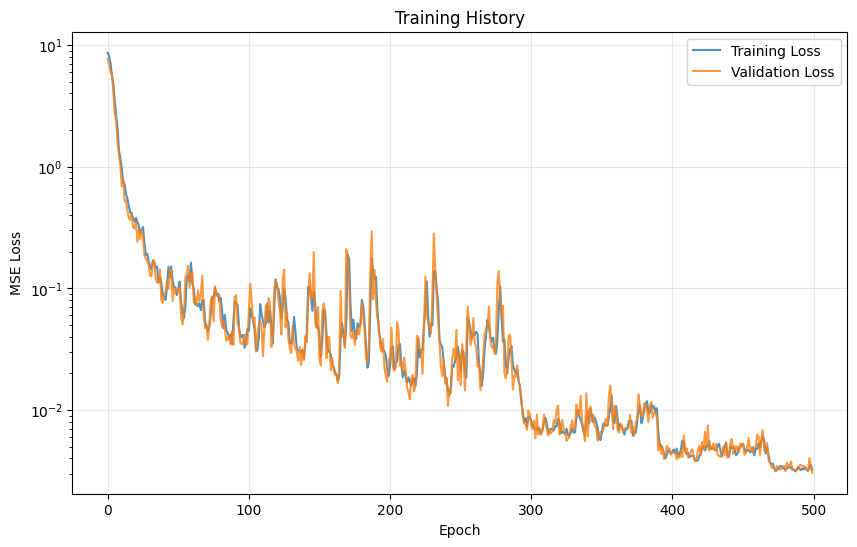

Training completed!
Final training loss: 0.003225
Final validation loss: 0.003051


In [29]:
def train_deeponet(model, train_loader, val_loader, num_epochs=500, lr=0.01):
    """Train the DeepONet model"""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)
    criterion = nn.MSELoss()
    
    train_losses = []
    val_losses = []
    
    best_val_loss = float('inf')
    patience = 100
    patience_counter = 0
    
    # Progress bar
    pbar = tqdm(range(num_epochs), desc="Training DeepONet")
    
    for epoch in pbar:
        # Training
        model.train()
        train_loss = 0.0
        for batch_coeffs, batch_x, batch_derivatives in train_loader:
            batch_coeffs = batch_coeffs.to(device)
            batch_x = batch_x.to(device)
            batch_derivatives = batch_derivatives.to(device)
            
            optimizer.zero_grad()
            output = model(batch_coeffs, batch_x)
            loss = criterion(output, batch_derivatives)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_coeffs, batch_x, batch_derivatives in val_loader:
                batch_coeffs = batch_coeffs.to(device)
                batch_x = batch_x.to(device)
                batch_derivatives = batch_derivatives.to(device)
                
                output = model(batch_coeffs, batch_x)
                loss = criterion(output, batch_derivatives)
                val_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        scheduler.step(avg_val_loss)
        
        # Update progress bar
        pbar.set_postfix({
            'Train': f'{avg_train_loss:.6f}',
            'Val': f'{avg_val_loss:.6f}',
            'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
        })
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\\nEarly stopping at epoch {epoch}')
                break
    
    pbar.close()
    return train_losses, val_losses

print("\n=== TRAINING ===")
train_loader, val_loader, test_data = setup_data_loaders(coeffs, x, derivatives, batch_size=128)

print(f"Data splits:")
print(f"- Training batches: {len(train_loader)} (batch size: 128)")
print(f"- Validation batches: {len(val_loader)}")
print(f"- Test samples: {len(test_data[0])}")

print("\\nStarting training...")
train_losses, val_losses = train_deeponet(model, train_loader, val_loader, num_epochs=500, lr=0.01)

# Plot training curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.8)
plt.plot(val_losses, label='Validation Loss', alpha=0.8)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"Training completed!")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")

\n=== PREDICTION & EVALUATION ===
Average Test MSE: 0.003519
Test MSE std: 0.005744


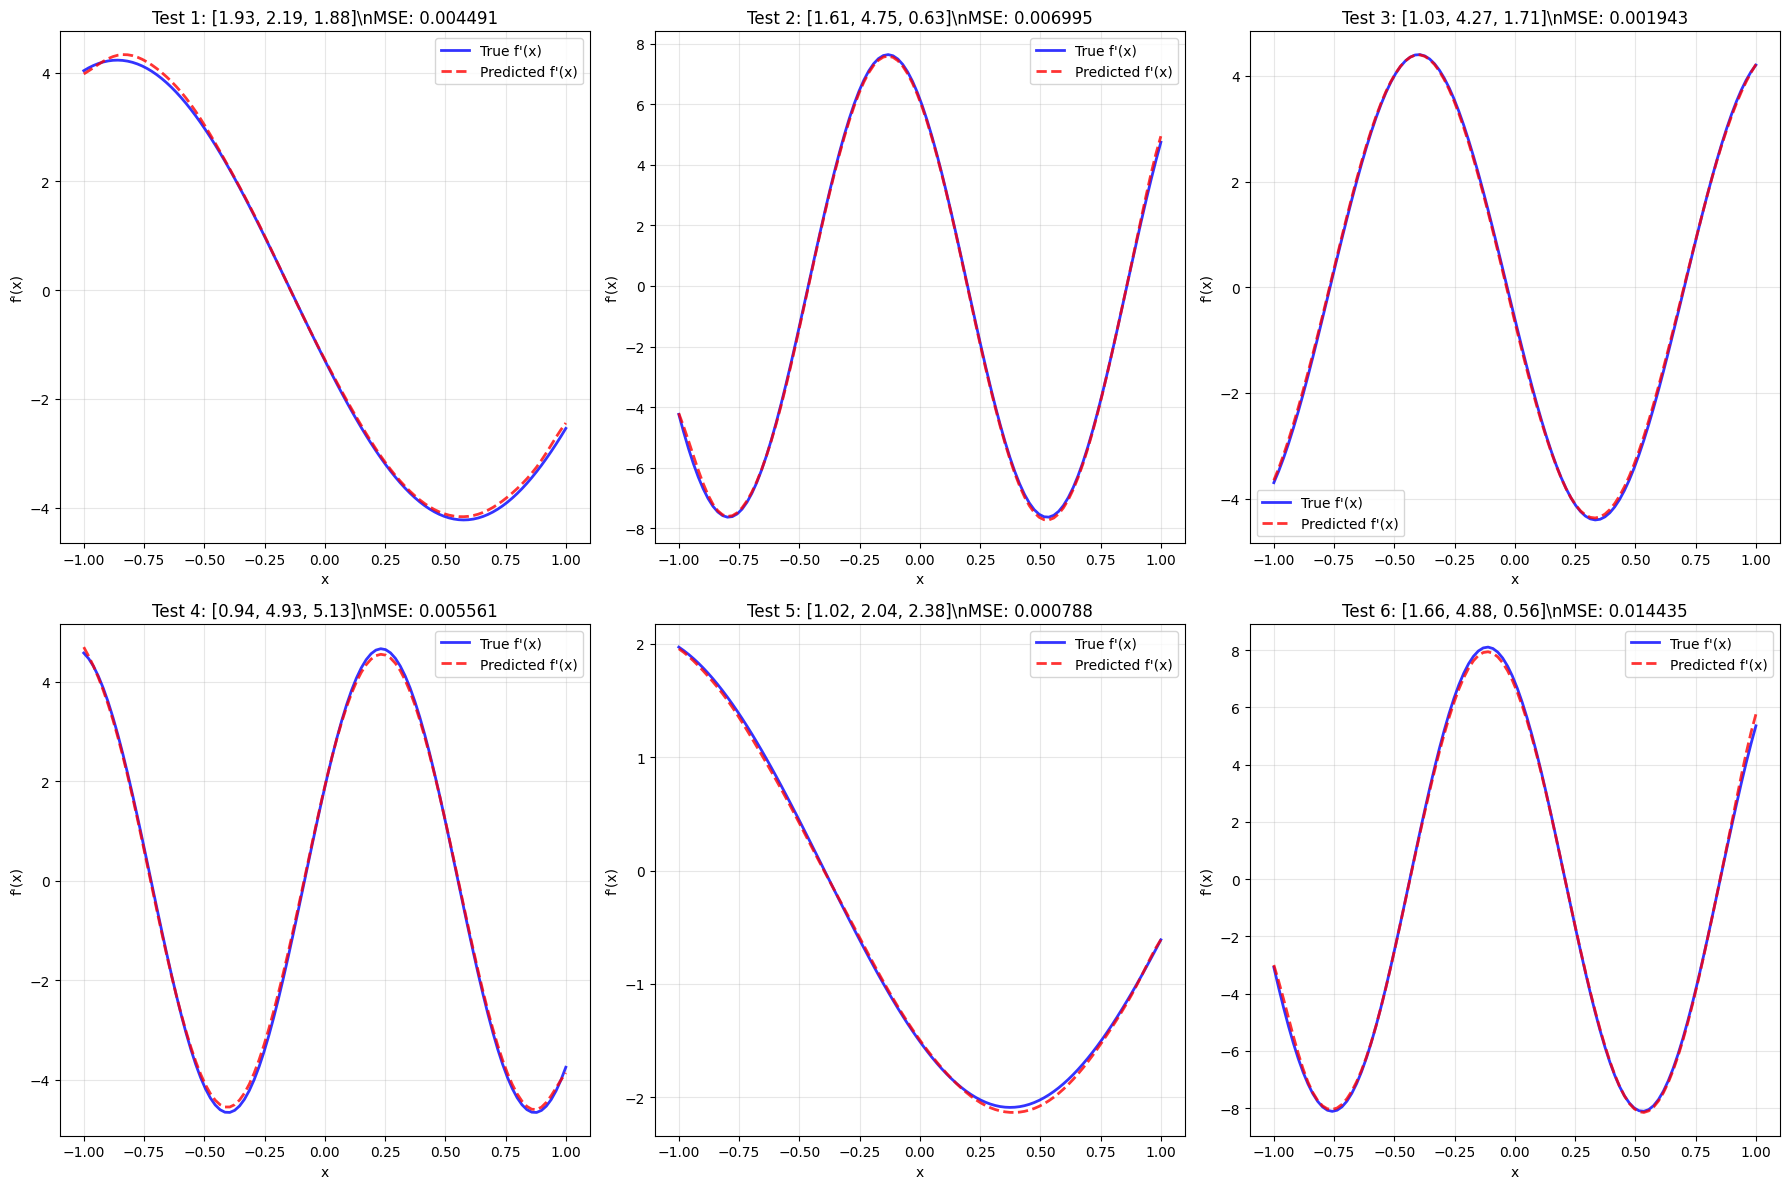

In [30]:
def evaluate_predictions(model, test_data, x):
    """Evaluate model predictions and create visualizations"""
    test_coeffs, test_derivatives = test_data
    model.eval()
    
    # Compute test errors
    test_errors = []
    predictions = []
    
    with torch.no_grad():
        for i in range(len(test_coeffs)):
            coeffs_tensor = torch.tensor(test_coeffs[i:i+1], dtype=torch.float32).to(device)
            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
            
            predicted = model(coeffs_tensor, x_tensor).cpu().numpy().flatten()
            true_derivative = test_derivatives[i]
            
            mse = np.mean((predicted - true_derivative)**2)
            test_errors.append(mse)
            predictions.append(predicted)
    
    avg_test_mse = np.mean(test_errors)
    print(f"Average Test MSE: {avg_test_mse:.6f}")
    print(f"Test MSE std: {np.std(test_errors):.6f}")
    
    return predictions, test_errors

print("\\n=== PREDICTION & EVALUATION ===")
predictions, test_errors = evaluate_predictions(model, test_data, x)
test_coeffs, test_derivatives = test_data

# Plot prediction results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot sample predictions
for i in range(6):
    ax = axes[i//3, i%3]
    
    ax.plot(x, test_derivatives[i], 'b-', linewidth=2, label='True f\'(x)', alpha=0.8)
    ax.plot(x, predictions[i], 'r--', linewidth=2, label='Predicted f\'(x)', alpha=0.8)
    
    # Show coefficients and error
    coeffs_str = ', '.join([f'{c:.2f}' for c in test_coeffs[i]])
    error = test_errors[i]
    ax.set_title(f'Test {i+1}: [{coeffs_str}]\\nMSE: {error:.6f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel("f'(x)")

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150)
plt.show()

In [31]:
# ========================= CELL 1: Data Generation =========================
def generate_special_wave_data(num_points=100, x_range=(-1, 1)):
    """Generate special wave functions and their derivatives"""
    np.random.seed(42)

    # Generate random coefficients for special wave functions: f(x) = a*sin(w*x + phi)
    # Sample parameters
    a_test = [1, 1, 2]        # Amplitude
    w_test = [1, 2, 3]    # Frequency
    phi_test = [0.0, 0.0, np.pi/4]  # Phase

    # Generate spatial points
    x = np.linspace(x_range[0], x_range[1], num_points)
    
    # Initialize arrays
    functions = np.zeros((3, num_points))
    derivatives = np.zeros((3, num_points))
    
    for i in range(3):
        a, w, phi = a_test[i], w_test[i], phi_test[i]
        # f(x) = a*sin(w*x + phi)
        functions[i] = a * np.sin(w * x + phi)
        # f'(x) = a*w*cos(w*x + phi)
        derivatives[i] = a * w * np.cos(w * x + phi)

    return np.column_stack((a_test, w_test, phi_test)), derivatives



### Special Cases

\n=== PREDICTION & EVALUATION ===
Average Test MSE: 0.010057
Test MSE std: 0.005100


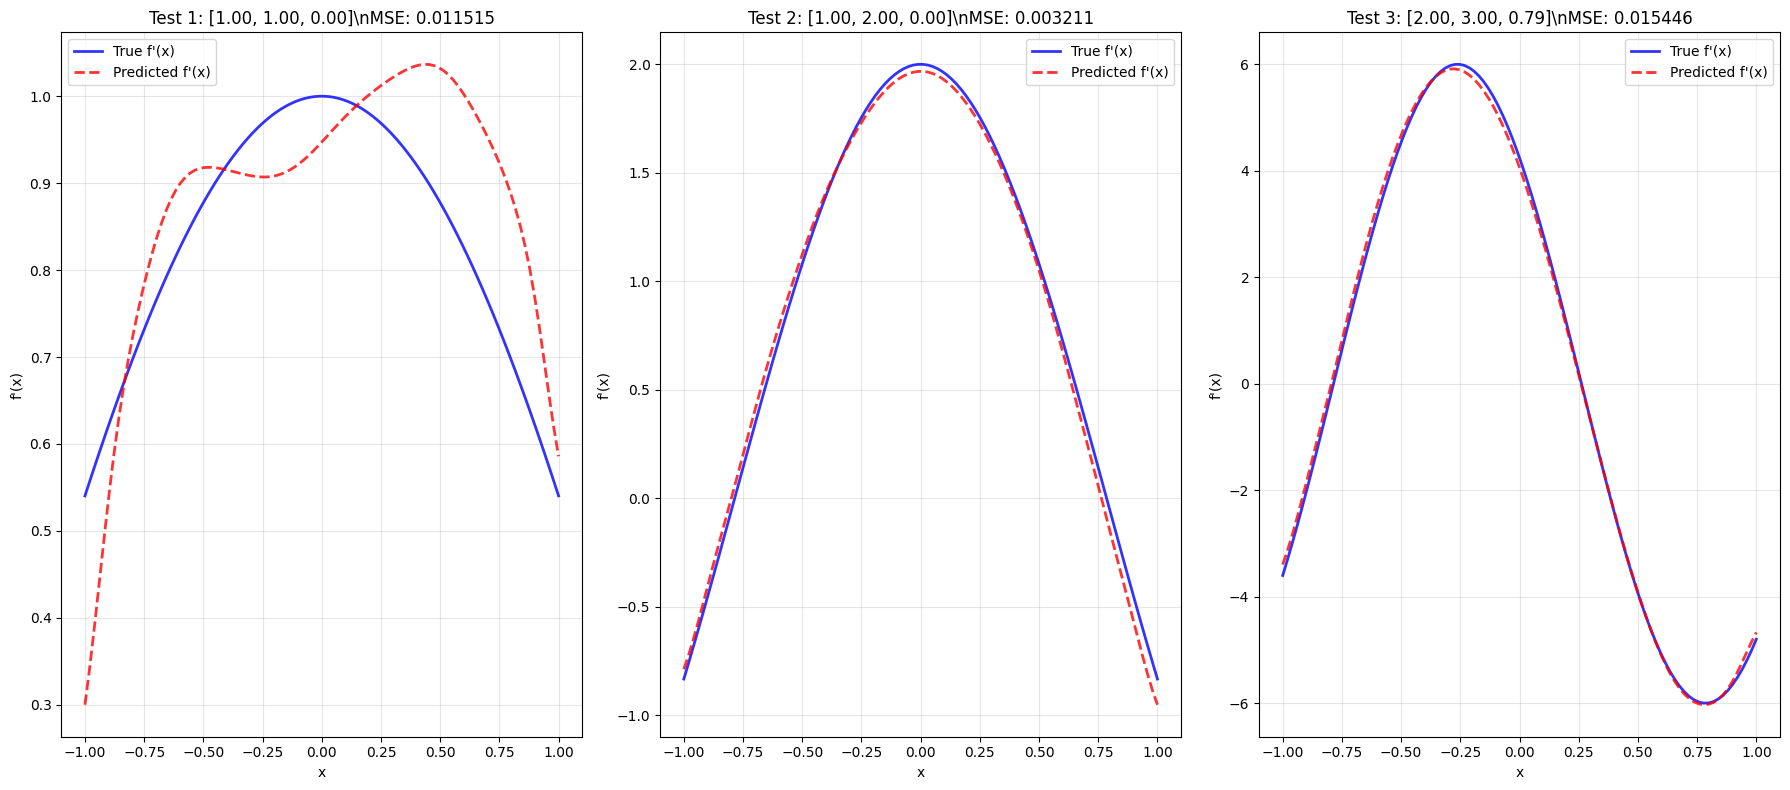

In [40]:
test_data = generate_special_wave_data(num_points=100)
print("\\n=== PREDICTION & EVALUATION ===")
predictions, test_errors = evaluate_predictions(model, test_data, x)
test_coeffs, test_derivatives = test_data

# Plot prediction results
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Plot sample predictions
for i in range(3):
    ax = axes[i]
    
    ax.plot(x, test_derivatives[i], 'b-', linewidth=2, label='True f\'(x)', alpha=0.8)
    ax.plot(x, predictions[i], 'r--', linewidth=2, label='Predicted f\'(x)', alpha=0.8)
    
    # Show coefficients and error
    coeffs_str = ', '.join([f'{c:.2f}' for c in test_coeffs[i]])
    error = test_errors[i]
    ax.set_title(f'Test {i+1}: [{coeffs_str}]\\nMSE: {error:.6f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel("f'(x)")

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150)
plt.show()

# Question 2

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

N_SOURCES = 1000          # number of source functions
nx = 100                  # grid points including boundaries x=0 and x=1
x = np.linspace(0.0, 1.0, nx)
dx = x[1] - x[0]
nu = 0.01                 # diffusion
c = 1.0                   # advection (positive -> upwind uses u_i - u_{i-1})
num_basis = 100           # number of basis / branch outputs (p)
EPOCHS = 3000             # per spec (reduce if you want a fast run)
BATCH_SIZE = 64
LR = 1e-3
WEIGHT_DECAY = 1e-5

In [4]:


def gen_source_coeffs(N):
    # c_n ~ N(0, (1/n)^2) for n=1..4
    cs = np.zeros((N, 4))
    for n in range(1, 5):
        sigma = (1.0 / n)**2
        cs[:, n-1] = np.random.normal(loc=0.0, scale=sigma, size=N)
    return cs

def build_f_from_cs(cs, x_grid):
    # cs: (N,4)
    N = cs.shape[0]
    f = np.zeros((N, x_grid.size))
    for i in range(N):
        # sum_{n=1..4} c_n sin(n*pi*x)
        vals = sum(cs[i, n-1] * np.sin(n * np.pi * x_grid) for n in range(1,5))
        f[i, :] = vals
    return f

def solve_bvp_fd(f_vals, nu=nu, c=c, x_grid=x):
    """
    Solve steady-state: nu u'' - c u' = f(x), u(0)=u(1)=0
    f_vals defined on full grid including boundaries (but f at boundaries used for interior RHS)
    Returns u on full grid (including endpoints).
    Using central difference for diffusion and upwind for advection (c>0).
    """
    nx = x_grid.size
    dx = x_grid[1] - x_grid[0]
    Nint = nx - 2
    # Build tridiagonal matrix A of size Nint x Nint for interior unknowns u_1..u_{nx-2}
    # For interior index i (global index i from 1..nx-2):
    # nu*(u_{i-1} - 2 u_i + u_{i+1})/dx^2 - c*(u_i - u_{i-1})/dx = f_i
    # Rearranged: (-nu/dx^2 + c/dx) * u_{i-1} + (2*nu/dx^2 - c/dx) * u_i + (-nu/dx^2) * u_{i+1} = f_i
    a = np.zeros(Nint)  # sub-diagonal (for u_{i-1})
    b = np.zeros(Nint)  # diagonal (for u_i)
    cdiag = np.zeros(Nint)  # super-diagonal (for u_{i+1})
    a[:] = (-nu / dx**2 + c / dx)
    b[:] = (2*nu / dx**2 - c / dx)
    cdiag[:] = (-nu / dx**2)

    # Build A once (same for all f) as dense/tridiag
    A = np.zeros((Nint, Nint))
    for i in range(Nint):
        A[i, i] = b[i]
        if i > 0:
            A[i, i-1] = a[i]
        if i < Nint - 1:
            A[i, i+1] = cdiag[i]

    # Pre-factorization could be used; here we use np.linalg.solve per sample
    # Solve for each f: interior RHS = f[1:-1]
    u_all = np.zeros_like(f_vals)
    for j in range(f_vals.shape[0]):
        rhs = f_vals[j, 1:-1].copy()
        # boundaries u(0)=u(1)=0 so no extra contribution
        u_interior = np.linalg.solve(A, rhs)
        u = np.zeros(f_vals.shape[1])
        u[1:-1] = u_interior
        # u[0] and u[-1] are 0 already
        u_all[j, :] = u
    return u_all

In [9]:
# Generate sources
cs = gen_source_coeffs(N_SOURCES)     # (N,4)
f_all = build_f_from_cs(cs, x)        # (N, nx)
# Solve for u for each source
u_all = solve_bvp_fd(f_all, nu=nu, c=c, x_grid=x)  # (N, nx)

# -------------------------------
# 2) Prepare training data
#    - Branch input: source sampled at nx points (we'll use the same 100-point grid)
#    - Trunk input: scalar x coordinate
#    - Target: u(x) at those nx points
# -------------------------------
# We'll predict u at interior + boundary points (nx). For DeepONet, branch is shape (N, nx)
branch_inputs = f_all.astype(np.float32)    # (N, nx)
trunk_x_grid = x.astype(np.float32)         # (nx,)

# Flatten targets for normalization (targets shape: N x nx)
targets = u_all.astype(np.float32)          # (N, nx)

# Normalize targets using training statistics (compute after train/test split)
# First split
train_idx, test_idx = train_test_split(np.arange(N_SOURCES), test_size=0.2, random_state=SEED)
branch_train = branch_inputs[train_idx]
branch_test = branch_inputs[test_idx]
targets_train = targets[train_idx]
targets_test = targets[test_idx]

# Compute train mean/std over all values
mu_u = targets_train.mean()
sigma_u = targets_train.std()
print(f"Target mean: {mu_u:.5e}, std: {sigma_u:.5e}")

# Normalize targets
targets_train_norm = (targets_train - mu_u) / (sigma_u + 1e-12)
targets_test_norm = (targets_test - mu_u) / (sigma_u + 1e-12)

# Convert to PyTorch tensors
# For training we will produce pairs (branch_vector, u_vector)
X_branch_train = torch.tensor(branch_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(targets_train_norm, dtype=torch.float32).to(device)
X_branch_test = torch.tensor(branch_test, dtype=torch.float32).to(device)
Y_test = torch.tensor(targets_test_norm, dtype=torch.float32).to(device)
x_grid_tensor = torch.tensor(trunk_x_grid, dtype=torch.float32).to(device)  # (nx,)

train_dataset = TensorDataset(X_branch_train, Y_train)
test_dataset = TensorDataset(X_branch_test, Y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Target mean: 5.03960e-03, std: 3.85639e-01


In [10]:
# -------------------------------
# 3) DeepONet model: Branch and Trunk nets
# -------------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=128, layers=3, activation=nn.Tanh):
        super().__init__()
        mlp = []
        dim = in_dim
        for i in range(layers):
            mlp.append(nn.Linear(dim, hidden))
            mlp.append(activation())
            dim = hidden
        mlp.append(nn.Linear(dim, out_dim))
        self.net = nn.Sequential(*mlp)
    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, nx_branch, p):
        super().__init__()
        # Branch: gets full f-vector (length nx_branch) -> outputs p coefficients
        self.branch = MLP(in_dim=nx_branch, out_dim=p, hidden=128, layers=3, activation=nn.Tanh)
        # Trunk: gets scalar x -> outputs p basis functions
        # We'll implement trunk to accept a batch of scalar x and output (batch, p)
        self.trunk = MLP(in_dim=1, out_dim=p, hidden=128, layers=3, activation=nn.Tanh)

    def forward(self, branch_vec, x_coords):
        """
        branch_vec: (B, nx_branch)
        x_coords: (M,) or (B, M) grid positions at which to evaluate trunk
        We'll produce output of shape (B, M) where M = number of x points (here nx)
        Implementation approach:
        - branch_out: (B, p)
        - trunk_out: (M, p)  if x_coords is global grid; or (B*M, p) if per-sample.
        We'll assume x_coords is a vector of grid points (M,) and evaluate same grid for all samples.
        """
        B = branch_vec.shape[0]
        M = x_coords.shape[0]
        p = self.branch.net[-1].out_features if hasattr(self.branch.net[-1], 'out_features') else self.branch.net[-1].weight.shape[0]
        # Branch -> (B, p)
        b = self.branch(branch_vec)          # (B, p)
        # Trunk: evaluate for all M x coords -> (M, p)
        x_in = x_coords.unsqueeze(1)         # (M,1)
        t = self.trunk(x_in)                 # (M, p)
        # Now compute output: for each sample b_i (p) and trunk t_m (p), output u_i(m) = sum_j b_i[j]*t_m[j]
        # We can do: (B, p) @ (p, M) -> (B, M)
        out = b @ t.t()                      # (B, M)
        return out

model = DeepONet(nx_branch=nx, p=num_basis).to(device)
print(model)


DeepONet(
  (branch): MLP(
    (net): Sequential(
      (0): Linear(in_features=100, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): Tanh()
      (6): Linear(in_features=128, out_features=100, bias=True)
    )
  )
  (trunk): MLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): Tanh()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): Tanh()
      (6): Linear(in_features=128, out_features=100, bias=True)
    )
  )
)


In [11]:
# -------------------------------
# 4) Training setup
# -------------------------------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# For logging
train_losses = []
val_losses = []

# Precompute x grid tensor (shared across batch)
x_grid = x_grid_tensor  # (nx,)

# Training loop
print("Begin training...")
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        # forward: xb (B, nx) -> output (B, nx)
        y_pred = model(xb, x_grid)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # validation
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred = model(xb, x_grid)
            val_running += criterion(y_pred, yb).item() * xb.size(0)
    val_loss = val_running / len(test_loader.dataset)
    val_losses.append(val_loss)

    scheduler.step()

    if epoch % 100 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"Epoch {epoch}/{EPOCHS} - Train Loss: {epoch_loss:.3e}  Val Loss: {val_loss:.3e}")

# -------------------------------
# 5) Evaluation: compute relative L2 error per test sample
# -------------------------------
model.eval()
with torch.no_grad():
    # Predict on test set
    Btest = X_branch_test.shape[0]
    y_pred_test = model(X_branch_test, x_grid)              # (Btest, nx) normalized
    # Denormalize
    y_pred_test_denorm = y_pred_test.cpu().numpy() * sigma_u + mu_u
    y_true_test_denorm = targets_test                      # numpy on device? earlier targets_test is numpy; we converted Y_test to tensor.
    # If Y_test was moved to device, get from original arrays:
    y_true_test_denorm = targets[test_idx]                 # (n_test, nx)
    # compute relative L2 error per sample
    rel_l2 = np.linalg.norm(y_pred_test_denorm - y_true_test_denorm, axis=1) / (np.linalg.norm(y_true_test_denorm, axis=1) + 1e-12)
    print(f"Relative L2 error on test (mean ± std): {rel_l2.mean():.5e} ± {rel_l2.std():.5e}")

Begin training...
Epoch 1/3000 - Train Loss: 2.765e-01  Val Loss: 8.041e-02
Epoch 100/3000 - Train Loss: 1.846e-02  Val Loss: 1.744e-02
Epoch 200/3000 - Train Loss: 9.947e-04  Val Loss: 2.137e-03
Epoch 300/3000 - Train Loss: 1.937e-03  Val Loss: 2.278e-03
Epoch 400/3000 - Train Loss: 1.639e-02  Val Loss: 1.754e-02
Epoch 500/3000 - Train Loss: 7.065e-04  Val Loss: 1.560e-03
Epoch 600/3000 - Train Loss: 7.716e-04  Val Loss: 1.636e-03
Epoch 700/3000 - Train Loss: 7.449e-04  Val Loss: 1.113e-03
Epoch 800/3000 - Train Loss: 2.994e-03  Val Loss: 1.914e-03
Epoch 900/3000 - Train Loss: 3.852e-04  Val Loss: 8.898e-04
Epoch 1000/3000 - Train Loss: 7.614e-04  Val Loss: 1.093e-03
Epoch 1100/3000 - Train Loss: 1.973e-04  Val Loss: 8.451e-04
Epoch 1200/3000 - Train Loss: 2.042e-03  Val Loss: 2.625e-03
Epoch 1300/3000 - Train Loss: 2.184e-04  Val Loss: 7.176e-04
Epoch 1400/3000 - Train Loss: 1.161e-04  Val Loss: 4.871e-04
Epoch 1500/3000 - Train Loss: 1.065e-04  Val Loss: 5.301e-04
Epoch 1600/3000 - 

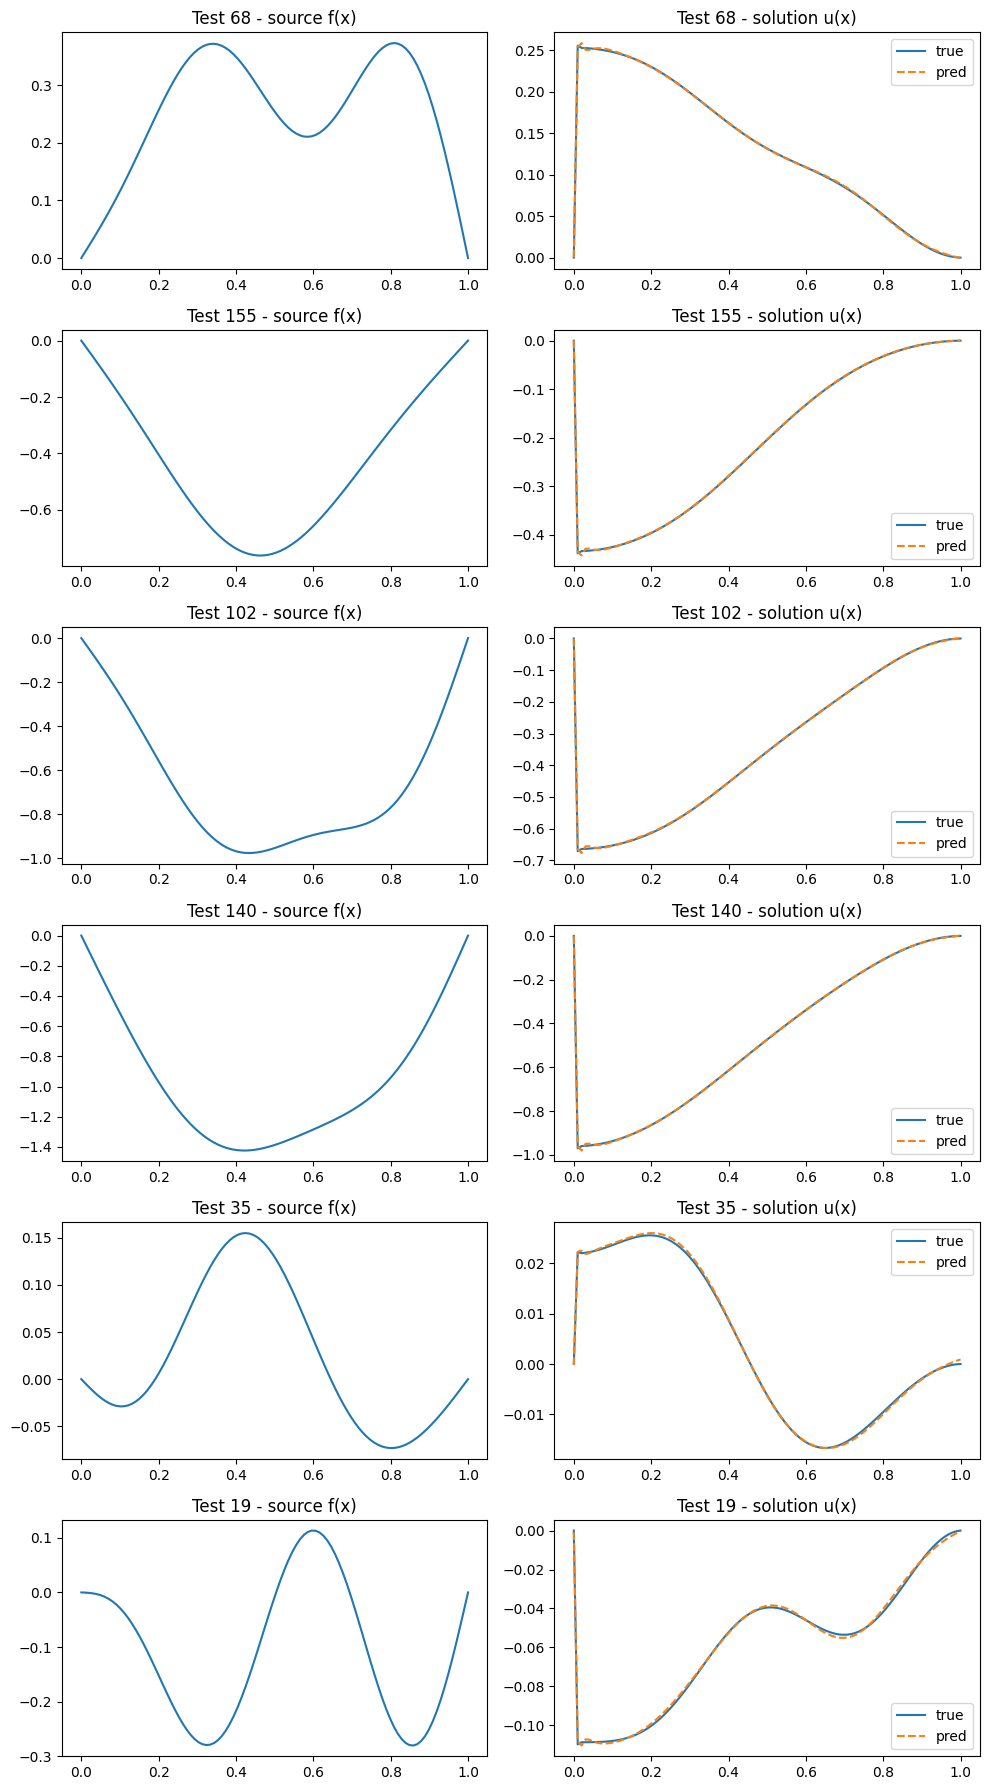

In [12]:
# -------------------------------
# 6) Plot 6 test cases (source f and solution true vs predicted)
# -------------------------------
import random
n_plot = 6
idxs = np.random.choice(np.arange(Btest), size=n_plot, replace=False)
fig, axes = plt.subplots(n_plot, 2, figsize=(10, 3*n_plot))
for i, idx in enumerate(idxs):
    fi = branch_test[idx]         # (nx,)
    ui_true = targets_test[idx]   # (nx,)
    ui_pred = y_pred_test_denorm[idx]
    axes[i,0].plot(x, fi)
    axes[i,0].set_title(f"Test {idx} - source f(x)")
    axes[i,1].plot(x, ui_true, label='true')
    axes[i,1].plot(x, ui_pred, '--', label='pred')
    axes[i,1].set_title(f"Test {idx} - solution u(x)")
    axes[i,1].legend()
plt.tight_layout()
plt.show()

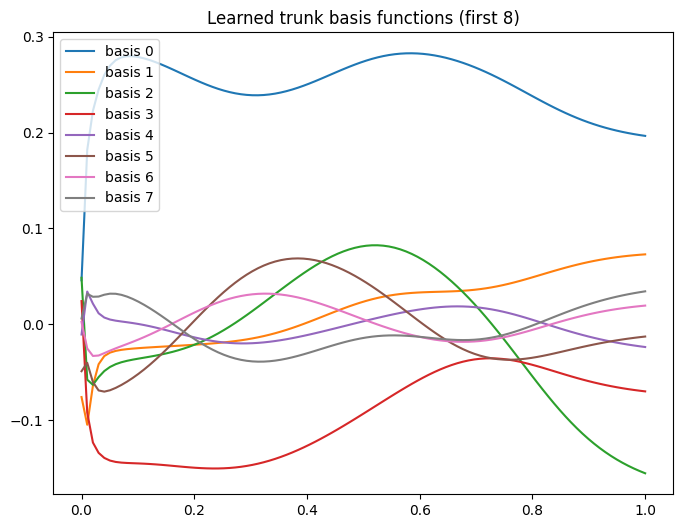

In [13]:
# -------------------------------
# 7) Visualize 8 learned basis functions (trunk outputs) vs x
# -------------------------------
# trunk outputs for x_grid: (nx, p)
with torch.no_grad():
    trunk_out = model.trunk(x_grid.unsqueeze(1)).cpu().numpy()  # (nx, p)
# pick 8 basis indices (e.g. first 8 or random)
basis_idx = list(range(8))
plt.figure(figsize=(8,6))
for j in basis_idx:
    plt.plot(x, trunk_out[:, j], label=f"basis {j}")
plt.title("Learned trunk basis functions (first 8)")
plt.legend()
plt.show()

In [14]:
# -------------------------------
# 8) Timing comparison: forward pass vs finite diff solver for a single sample
# -------------------------------
# pick a sample from test set
sample_idx = 0
branch_sample = branch_test[sample_idx:sample_idx+1]  # (1,nx)
f_sample = branch_sample.copy()
# time finite-difference solve (repeat many times to average)
n_reps = 200
t0 = time.time()
for _ in range(n_reps):
    u_fd = solve_bvp_fd(f_sample, nu=nu, c=c, x_grid=x)   # returns shape (1,nx)
t_fd = (time.time() - t0) / n_reps

# time DeepONet forward pass (repeat)
branch_tensor_single = torch.tensor(branch_sample, dtype=torch.float32).to(device)
t0 = time.time()
with torch.no_grad():
    for _ in range(n_reps):
        u_pred_norm = model(branch_tensor_single, x_grid)  # (1,nx)
t_do = (time.time() - t0) / n_reps

print(f"Avg time (per eval) finite-diff solver: {t_fd*1e3:.4f} ms")
print(f"Avg time (per eval) DeepONet forward pass: {t_do*1e3:.4f} ms")
print(f"Speedup (FD / DeepONet): {t_fd / t_do:.2f}x")

Avg time (per eval) finite-diff solver: 18.8406 ms
Avg time (per eval) DeepONet forward pass: 0.2920 ms
Speedup (FD / DeepONet): 64.52x


# Question 3

In [15]:
# -----------------------
# Config / Hyperparams
# -----------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Problem spec
N_SOURCES = 1000
nx = 100                     # number of grid points (m)
x_grid = np.linspace(0.0, 1.0, nx)
dx = x_grid[1] - x_grid[0]
nu_default = 0.01
c_default = 1.0

# PI-DeepONet architecture
p = 50                       # number basis / branch outputs
branch_hidden = 64
trunk_hidden = 64
branch_layers = 3
trunk_layers = 3

# Training
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
LAMBDA_PHYS = 1.0
LAMBDA_BC = 10.0
EPOCHS = 1000
PATIENCE_PLATEAU = 100
PATIENCE_EARLYSTOP = 200

In [18]:
# -----------------------
# (A) Dataset generation (same as Q2)
# - f(x) = sum_{n=1..4} c_n sin(n*pi*x), c_n ~ N(0, (1/n)^2)
# - Solve BVP using finite differences (central diff for diffusion, upwind for advection c>0)
# The script will try to load './advecdiff_dataset.npz' if present; otherwise it regenerates.
# -----------------------
def gen_source_coeffs(N):
    cs = np.zeros((N, 4))
    for n in range(1, 5):
        sigma = 1.0 / n
        cs[:, n-1] = np.random.normal(loc=0.0, scale=sigma, size=N)
    return cs

def build_f_from_cs(cs, x):
    N = cs.shape[0]
    f = np.zeros((N, x.size))
    for i in range(N):
        vals = sum(cs[i, n-1] * np.sin(n * np.pi * x) for n in range(1, 5))
        f[i, :] = vals
    return f

def solve_bvp_fd_batch(f_vals, nu=nu_default, c=c_default, x_grid=x_grid):
    # f_vals: (N, nx)
    nx_local = x_grid.size
    dx_local = x_grid[1] - x_grid[0]
    Nint = nx_local - 2
    # coefficients as per discretization in prompt
    a = (-nu / dx_local**2 + c / dx_local)      # sub-diagonal
    b = (2*nu / dx_local**2 - c / dx_local)     # diagonal
    cdiag = (-nu / dx_local**2)                 # super-diagonal
    # Build tridiagonal matrix A (Nint x Nint)
    A = np.zeros((Nint, Nint))
    for i in range(Nint):
        A[i, i] = b
        if i > 0:
            A[i, i-1] = a
        if i < Nint - 1:
            A[i, i+1] = cdiag
    # Solve for each sample's interior (u1..u_{nx-2}) with Dirichlet BCs u0=un=0
    Nsamples = f_vals.shape[0]
    u_all = np.zeros_like(f_vals)
    for j in range(Nsamples):
        rhs = f_vals[j, 1:-1].copy()
        u_interior = np.linalg.solve(A, rhs)
        u = np.zeros(f_vals.shape[1])
        u[1:-1] = u_interior
        u_all[j, :] = u
    return u_all

dataset_path = "advecdiff_dataset.npz"
if os.path.exists(dataset_path):
    print("Loading dataset from", dataset_path)
    data = np.load(dataset_path)
    f_all = data["f_all"]
    u_all = data["u_all"]
    cs = data.get("cs", None)
else:
    print("Generating dataset (this may take a moment)...")
    cs = gen_source_coeffs(N_SOURCES)
    f_all = build_f_from_cs(cs, x_grid)     # (N, nx)
    u_all = solve_bvp_fd_batch(f_all, nu=nu_default, c=c_default, x_grid=x_grid)
    np.savez_compressed(dataset_path, f_all=f_all, u_all=u_all, cs=cs)
    print("Saved dataset to", dataset_path)

Generating dataset (this may take a moment)...
Saved dataset to advecdiff_dataset.npz


In [19]:
# -----------------------
# Prepare inputs for PI-DeepONet
# Branch input: [f(x1),...,f(xm), nu, c]  -> length = nx + 2
# Trunk input: scalar x  -> single coordinate
# Targets: u(x) on grid (nx)
# -----------------------
# Expand nu and c to match sample count (we keep nu and c same across dataset but code supports variability)
nu_vals = np.full((f_all.shape[0], 1), nu_default, dtype=np.float32)
c_vals = np.full((f_all.shape[0], 1), c_default, dtype=np.float32)
branch_inputs = np.hstack([f_all.astype(np.float32), nu_vals, c_vals])  # (N, nx+2)
targets = u_all.astype(np.float32)                                      # (N, nx)

# Train/test split
train_idx, test_idx = train_test_split(np.arange(f_all.shape[0]), test_size=0.2, random_state=SEED)
branch_train = branch_inputs[train_idx]
branch_test = branch_inputs[test_idx]
targets_train = targets[train_idx]
targets_test = targets[test_idx]

# Compute normalization statistics on training targets (for stability)
mu_u = targets_train.mean()
sigma_u = targets_train.std()
print("Targets train mean:", mu_u, "std:", sigma_u)

Targets train mean: 0.002565606 std: 0.39939752


In [20]:
# Normalize targets for data-loss part. We'll compute physics residual on denormalized predictions.
targets_train_norm = (targets_train - mu_u) / (sigma_u + 1e-12)
targets_test_norm = (targets_test - mu_u) / (sigma_u + 1e-12)

# Convert to tensors
X_branch_train = torch.tensor(branch_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(targets_train_norm, dtype=torch.float32).to(device)
X_branch_test = torch.tensor(branch_test, dtype=torch.float32).to(device)
Y_test = torch.tensor(targets_test_norm, dtype=torch.float32).to(device)

x_grid_tensor = torch.tensor(x_grid, dtype=torch.float32).to(device)    # shape (nx,)
# For some autograd operations we will need x_grid with requires_grad=True (create per-batch when computing physics)

train_loader = DataLoader(TensorDataset(X_branch_train, Y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_branch_test, Y_test), batch_size=BATCH_SIZE, shuffle=False)


In [21]:
# -----------------------
# Model definition
# -----------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, layers=3, activation=nn.Tanh):
        super().__init__()
        seq = []
        dim = in_dim
        for _ in range(layers):
            seq.append(nn.Linear(dim, hidden))
            seq.append(activation())
            dim = hidden
        seq.append(nn.Linear(dim, out_dim))
        self.net = nn.Sequential(*seq)
    def forward(self, x):
        return self.net(x)

class PI_DeepONet(nn.Module):
    def __init__(self, nx_branch, p):
        super().__init__()
        self.p = p
        self.branch = MLP(in_dim=nx_branch, out_dim=p, hidden=branch_hidden, layers=branch_layers, activation=nn.Tanh)
        self.trunk = MLP(in_dim=1, out_dim=p, hidden=trunk_hidden, layers=trunk_layers, activation=nn.Tanh)

    def forward(self, branch_vec, x_coords):
        # branch_vec: (B, nx+2)
        # x_coords: (M,) - grid points (same for all samples in a batch)
        B = branch_vec.shape[0]
        M = x_coords.shape[0]
        # Branch output: (B, p)
        b = self.branch(branch_vec)                        # (B, p)
        # Trunk output: (M, p)
        # x_coords expected shape (M,) or (M,1). Ensure shape (M,1)
        x_in = x_coords.unsqueeze(1)                       # (M,1)
        t = self.trunk(x_in)                               # (M, p)
        # Output u_pred (B, M): b @ t.T
        out = b @ t.t()
        return out, b, t

model = PI_DeepONet(nx_branch=nx+2, p=p).to(device)
print(model)


PI_DeepONet(
  (branch): MLP(
    (net): Sequential(
      (0): Linear(in_features=102, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): Tanh()
      (6): Linear(in_features=64, out_features=50, bias=True)
    )
  )
  (trunk): MLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=64, bias=True)
      (5): Tanh()
      (6): Linear(in_features=64, out_features=50, bias=True)
    )
  )
)


In [22]:
# -----------------------
# Training utilities: compute derivatives of trunk wrt x using autograd
# Approach:
#   trunk(x_in) -> t shape (M,p). For each basis j, compute grad_j = d/dx (t[:,j]) by
#   torch.autograd.grad(t[:,j].sum(), x_in, create_graph=True)[0] -> returns (M,1) containing derivatives
#   Stack across j to get dt_dx (M,p). Then:
#       du_dx = b @ dt_dx.T   (B,M)
#       d2u_dx2: differentiate grad_j again wrt x_in to get d2t/dx2 (M,p) similarly.
# -----------------------
def compute_trunk_derivatives(trunk_net, x_coords):
    """
    x_coords: tensor with requires_grad=True, shape (M,1)
    returns:
      t: (M,p)
      dt_dx: (M,p)
      d2t_dx2: (M,p)
    """
    t = trunk_net(x_coords)             # (M,p)
    M, p_local = t.shape
    dt_dx_cols = []
    d2t_dx2_cols = []
    # For each basis index j compute derivative w.r.t x_coords
    for j in range(p_local):
        # sum over M entries of basis j to allow vector-Jacobian computation
        tj = t[:, j]                    # (M,)
        grad_tj = torch.autograd.grad(tj.sum(), x_coords, create_graph=True, retain_graph=True)[0]  # (M,1)
        grad_tj = grad_tj.view(-1)      # (M,)
        dt_dx_cols.append(grad_tj)
        # second derivative:
        grad2_tj = torch.autograd.grad(grad_tj.sum(), x_coords, create_graph=True, retain_graph=True)[0]  # (M,1)
        grad2_tj = grad2_tj.view(-1)
        d2t_dx2_cols.append(grad2_tj)
    dt_dx = torch.stack(dt_dx_cols, dim=1)        # (M, p)
    d2t_dx2 = torch.stack(d2t_dx2_cols, dim=1)   # (M, p)
    return t, dt_dx, d2t_dx2

# -----------------------
# Optimizer, scheduler, early stopping
# -----------------------
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=PATIENCE_PLATEAU, factor=0.5, verbose=True)

# Early stopping util
class EarlyStopper:
    def __init__(self, patience=200):
        self.patience = patience
        self.best = float('inf')
        self.counter = 0
    def step(self, value):
        if value < self.best:
            self.best = value
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

earlystop = EarlyStopper(patience=PATIENCE_EARLYSTOP)

# Logging containers
history = {
    "epoch": [], "loss_total": [], "loss_data": [], "loss_phys": [], "loss_bc": [], "val_loss": []
}

c:\Users\emman\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [23]:
# -----------------------
# Training loop
# -----------------------
print("Begin training PI-DeepONet...")
start_time = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    epoch_data = 0.0
    epoch_phys = 0.0
    epoch_bc = 0.0
    n_batches = 0

    for xb, yb in train_loader:
        n_batches += 1
        optimizer.zero_grad()

        # xb: (B, nx+2)
        # split branch features and params (we stored nu,c appended in branch)
        # We will assume last two entries are nu and c per-sample (they might be identical across dataset)
        branch_features = xb  # full branch

        # Prepare x coordinates with requires_grad for autograd
        x_coords = x_grid_tensor.clone().detach().to(device).requires_grad_(True)  # (nx,)

        # Forward
        u_pred_norm, b_out, t_out = model(branch_features, x_coords)  # (B, M), (B,p), (M,p)
        # Data loss (on normalized targets)
        data_loss = nn.MSELoss()(u_pred_norm, yb)

        # Denormalize for physics residual and BCs
        u_pred = u_pred_norm * (sigma_u + 1e-12) + mu_u   # (B, M) in original u scale
        # compute derivatives via trunk derivatives
        # t_out is (M, p) and computed with x_coords.requires_grad=True so we can differentiate
        t, dt_dx, d2t_dx2 = compute_trunk_derivatives(model.trunk, x_coords.unsqueeze(1))  # t:(M,p), dt_dx:(M,p), d2t_dx2:(M,p)
        # du_dx = b @ dt_dx.T -> (B, M)
        du_dx = b_out @ dt_dx.t()
        d2u_dx2 = b_out @ d2t_dx2.t()

        # Physics residual r = nu * d2u/dx2 - c * du/dx - f
        # Need f in original scale: f_i(xj) is branch first nx entries
        f_batch = branch_features[:, :nx]  # (B, M)
        nu_batch = branch_features[:, nx].view(-1, 1)  # (B,1)
        c_batch = branch_features[:, nx+1].view(-1, 1) # (B,1)
        # Expand nu and c to (B, M)
        nu_expand = nu_batch.expand(-1, x_coords.shape[0])
        c_expand = c_batch.expand(-1, x_coords.shape[0])

        physics_residual = nu_expand * d2u_dx2 - c_expand * du_dx - f_batch  # (B, M)
        physics_loss = torch.mean(physics_residual**2)

        # Boundary loss (u_pred at x=0 and x=1)
        # endpoints are indices 0 and nx-1
        u0 = u_pred[:, 0]
        u1 = u_pred[:, -1]
        bc_loss = torch.mean(u0**2 + u1**2)

        loss = data_loss + LAMBDA_PHYS * physics_loss + LAMBDA_BC * bc_loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_data += data_loss.item()
        epoch_phys += physics_loss.item()
        epoch_bc += bc_loss.item()

    # average over batches
    epoch_loss /= n_batches
    epoch_data /= n_batches
    epoch_phys /= n_batches
    epoch_bc /= n_batches

    # Validation loss (use data loss + physics + BC aggregated on validation set)
    model.eval()
    val_loss_accum = 0.0
    with torch.no_grad():
        for xb_val, yb_val in val_loader:
            # forward pass with no grad for trunk derivatives for speed; for validation physics term we could compute, but we evaluate data loss primarily for scheduler
            x_coords_val = x_grid_tensor.clone().detach().to(device).requires_grad_(True)
            u_pred_norm_val, bval, tval = model(xb_val, x_coords_val)
            # Data loss
            data_loss_val = nn.MSELoss()(u_pred_norm_val, yb_val)
            # do physics residual with autograd disabled? to compute physics term for full val loss we need grads -> compute with torch.enable_grad temporarily
            # For scheduler we use validation data loss only (common practice). But we also log physics/BC on train side.
            val_loss_accum += data_loss_val.item()

    val_loss = val_loss_accum / len(val_loader)

    # Scheduler step
    scheduler.step(val_loss)

    # Logging
    history["epoch"].append(epoch)
    history["loss_total"].append(epoch_loss)
    history["loss_data"].append(epoch_data)
    history["loss_phys"].append(epoch_phys)
    history["loss_bc"].append(epoch_bc)
    history["val_loss"].append(val_loss)

    if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"Epoch {epoch:04d}  total={epoch_loss:.3e}  data={epoch_data:.3e}  phys={epoch_phys:.3e}  bc={epoch_bc:.3e}  val_data={val_loss:.3e}")

    # Early stopping monitor using validation data loss
    if earlystop.step(val_loss):
        print(f"Early stopping at epoch {epoch}. Best val loss: {earlystop.best:.3e}")
        break

elapsed = time.time() - start_time
print(f"Training completed in {elapsed/60:.2f} minutes (epochs run: {len(history['epoch'])})")


Begin training PI-DeepONet...
Epoch 0001  total=1.255e+00  data=6.389e-01  phys=3.875e-01  bc=2.288e-02  val_data=5.006e-01
Epoch 0010  total=9.192e-01  data=5.042e-01  phys=1.757e-01  bc=2.393e-02  val_data=4.639e-01
Epoch 0020  total=8.578e-01  data=5.022e-01  phys=1.167e-01  bc=2.389e-02  val_data=4.671e-01
Epoch 0030  total=8.357e-01  data=5.005e-01  phys=9.544e-02  bc=2.397e-02  val_data=4.564e-01
Epoch 0040  total=8.272e-01  data=5.002e-01  phys=8.774e-02  bc=2.393e-02  val_data=4.614e-01
Epoch 0050  total=8.195e-01  data=4.999e-01  phys=8.023e-02  bc=2.394e-02  val_data=4.532e-01
Epoch 0060  total=8.186e-01  data=4.993e-01  phys=7.996e-02  bc=2.394e-02  val_data=4.535e-01
Epoch 0070  total=8.168e-01  data=4.990e-01  phys=7.894e-02  bc=2.389e-02  val_data=4.648e-01
Epoch 0080  total=8.185e-01  data=4.993e-01  phys=7.943e-02  bc=2.398e-02  val_data=4.756e-01
Epoch 0090  total=8.179e-01  data=4.986e-01  phys=7.925e-02  bc=2.400e-02  val_data=4.493e-01
Epoch 0100  total=8.177e-01  d

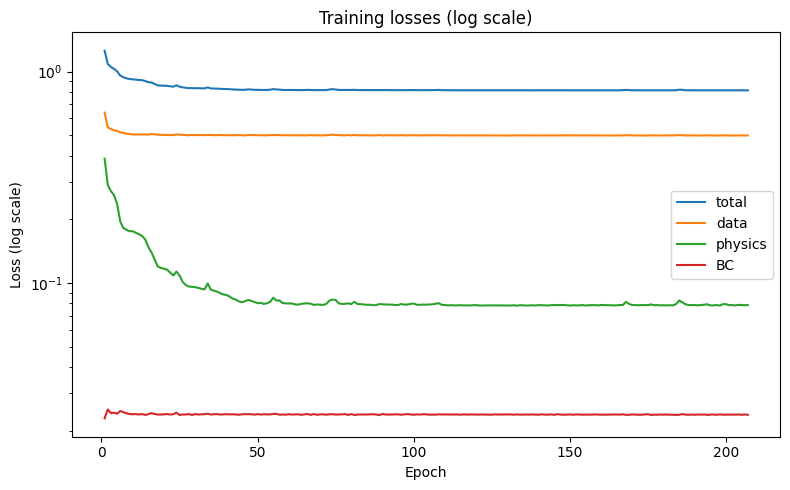

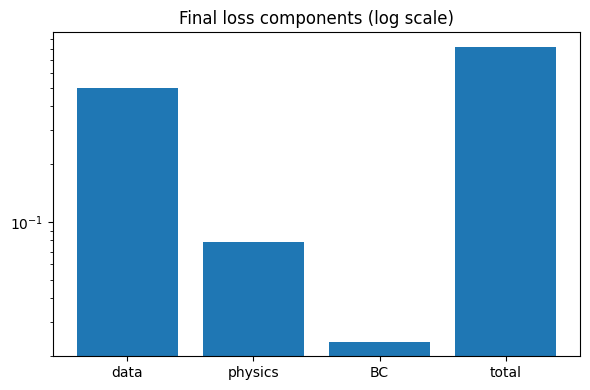

In [24]:
# -----------------------
# (f) Plot losses (log scale) and bar chart of final loss components
# -----------------------
import matplotlib.pyplot as plt
epochs_ran = history["epoch"]

plt.figure(figsize=(8,5))
plt.semilogy(epochs_ran, history["loss_total"], label="total")
plt.semilogy(epochs_ran, history["loss_data"], label="data")
plt.semilogy(epochs_ran, history["loss_phys"], label="physics")
plt.semilogy(epochs_ran, history["loss_bc"], label="BC")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.legend()
plt.title("Training losses (log scale)")
plt.tight_layout()
plt.show()

# Bar chart of final losses (train last logged batch-averaged values)
final_data = history["loss_data"][-1]
final_phys = history["loss_phys"][-1]
final_bc = history["loss_bc"][-1]
final_total = history["loss_total"][-1]

plt.figure(figsize=(6,4))
plt.bar(["data","physics","BC","total"], [final_data, final_phys, final_bc, final_total])
plt.yscale("log")
plt.title("Final loss components (log scale)")
plt.tight_layout()
plt.show()

In [25]:
# -----------------------
# (g) Evaluation metrics on test set
# - Average relative L2 error
# - Average physics residual: mean |nu u'' - c u' - f|
# - Average boundary error: mean (|u(0)| + |u(1)|)
# -----------------------
model.eval()
with torch.no_grad():
    X_test_np = branch_test  # (Ntest, nx+2) numpy
    Y_true = targets_test    # (Ntest, nx) original scale

    # Convert to tensor for prediction
    X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32).to(device)
    n_test = X_test_tensor.shape[0]
    # Predict in batches
    preds = []
    for i in range(0, n_test, BATCH_SIZE):
        xb_batch = X_test_tensor[i:i+BATCH_SIZE]
        # forward (x_grid no grad needed for prediction)
        u_pred_norm_batch, _, _ = model(xb_batch, x_grid_tensor)
        u_pred_batch = (u_pred_norm_batch.cpu().numpy() * (sigma_u + 1e-12) + mu_u)  # denormalize
        preds.append(u_pred_batch)
    preds = np.vstack(preds)  # (Ntest, nx)

# relative L2 per sample
rel_l2s = np.linalg.norm(preds - Y_true, axis=1) / (np.linalg.norm(Y_true, axis=1) + 1e-12)
avg_rel_l2 = rel_l2s.mean()

# compute physics residuals and BC errors (we compute numerically using autograd for derivatives on CPU)
# we'll compute derivatives via central difference on preds for simplicity for these metrics
preds_dx = np.gradient(preds, dx, axis=1)         # (Ntest, nx)
preds_d2x2 = np.gradient(preds_dx, dx, axis=1)   # (Ntest, nx)
f_test = branch_test[:, :nx]                     # (Ntest, nx)
nu_test = branch_test[:, nx].reshape(-1,1)
c_test = branch_test[:, nx+1].reshape(-1,1)

phys_res = np.abs(nu_test * preds_d2x2 - c_test * preds_dx - f_test)   # (Ntest, nx)
avg_phys_res = phys_res.mean()

bc_errors = np.abs(preds[:, 0]) + np.abs(preds[:, -1])   # (Ntest,)
avg_bc_error = bc_errors.mean()

print(f"Evaluation on test set (n={preds.shape[0]}):")
print(f"Average relative L2 error: {avg_rel_l2:.5e}")
print(f"Average physics residual (mean abs): {avg_phys_res:.5e}")
print(f"Average boundary error (mean |u(0)|+|u(1)|): {avg_bc_error:.5e}")


Evaluation on test set (n=200):
Average relative L2 error: 6.89904e-01
Average physics residual (mean abs): 4.23832e-01
Average boundary error (mean |u(0)|+|u(1)|): 1.31499e-01


### Summary
> The regular DeepONet model performed better than the PINN DeepONet in both accuracy and training time. However, the case of accuracy should be noted that we employed less epoch for the PINN DeepONet because of the long training time.